In [18]:
%reload_ext autoreload
%autoreload 2
%cd ~/erc-src/cuneiform-ocr-sign-alignment-worktree # Change to the project directory
%env PATH=$HOME/.local/bin:$PATH
    
import json
import os
import requests
import numpy as np
import cv2
from PIL import Image
from pymongo import MongoClient
# from mmdet.apis import init_detector, inference_detector
# from mmdet.utils import register_all_modules
from data_processing.divide_photos import divide_tablet_photo
from sign_alignment.detector import ModelConfig, TabletImageDetector

# import signs_alignment as sa
import os
import torch
from dotenv import load_dotenv

ANNOTATIONS_DIR = os.path.expanduser("~/erc-work-data/data-of-cuneiform-ocr-data/filtered_annotations")
CONFIG_FILE = "configs/detr.py"
CHECKPOINT_FILE = os.path.expanduser("~/erc-work-data/retrained_models/detr-173/epoch_1000.pth")
SCORE_THRESHOLD = 0.5
Y_THRESHOLD = 35  # for grouping signs into lines
OUTPUT_DIR = "alignment_results"
SAMPLE_LIMIT = 5  # number of samples to process

load_dotenv()
MONGODB_URI = os.getenv('MONGODB_URI', 'YOUR_MONGODB_URI')

[Errno 2] No such file or directory: '/home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree # Change to the project directory'
/home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree
env: PATH=$HOME/.local/bin:$PATH


In [11]:
model_config = ModelConfig(
    config_file=CONFIG_FILE,
    checkpoint_file=CHECKPOINT_FILE,
    device='auto'
)
tablet_detector = TabletImageDetector(
    model_config=model_config,
    score_threshold=SCORE_THRESHOLD,
    keep_crops=True
)

Initializing detector, loading model...
Using device: cuda:0
Loads checkpoint by local backend from path: /home/jebediahc/erc-work-data/retrained_models/detr-173/epoch_1000.pth


In [12]:
from sign_alignment.data_source import LocalDataSource

local_source = LocalDataSource(ANNOTATIONS_DIR)
fragments = local_source.get_available_fragments()
print(f"Found {len(fragments)} fragments with both image and annotation")
sample = fragments[0]
print(f"Processing sample: {sample}")

Found 947 fragments with both image and annotation
Processing sample: NBC.4020


Ground truth boxes: [BoundingBox(x1=2336.0, y1=1246.0, x2=2442.0, y2=1408.0, score=1.0, sign=Sign(abz='ABZ579', name='A', idx=11)), BoundingBox(x1=2463.0, y1=1193.0, x2=2755.0, y2=1398.0, score=1.0, sign=Sign(abz='ABZ70', name='NA', idx=34)), BoundingBox(x1=2753.0, y1=1167.0, x2=3065.0, y2=1397.0, score=1.0, sign=Sign(abz='ABZ371', name='BU', idx=91)), BoundingBox(x1=3078.0, y1=1164.0, x2=3231.0, y2=1384.0, score=1.0, sign=Sign(abz='ABZ586', name='ZA', idx=10)), BoundingBox(x1=3245.0, y1=1174.0, x2=3492.0, y2=1370.0, score=1.0, sign=Sign(abz='ABZ6', name='ZU', idx=70)), BoundingBox(x1=2281.0, y1=1402.0, x2=2465.0, y2=1591.0, score=1.0, sign=Sign(abz='ABZ461', name='KI', idx=45)), BoundingBox(x1=3230.0, y1=1334.0, x2=3506.0, y2=1520.0, score=1.0, sign=Sign(abz='ABZ134', name='UM', idx=113)), BoundingBox(x1=3496.0, y1=1305.0, x2=3811.0, y2=1499.0, score=1.0, sign=Sign(abz='ABZ342', name='MA', idx=21)), BoundingBox(x1=2782.0, y1=1358.0, x2=3116.0, y2=1557.0, score=1.0, sign=Sign(abz='ABZ3

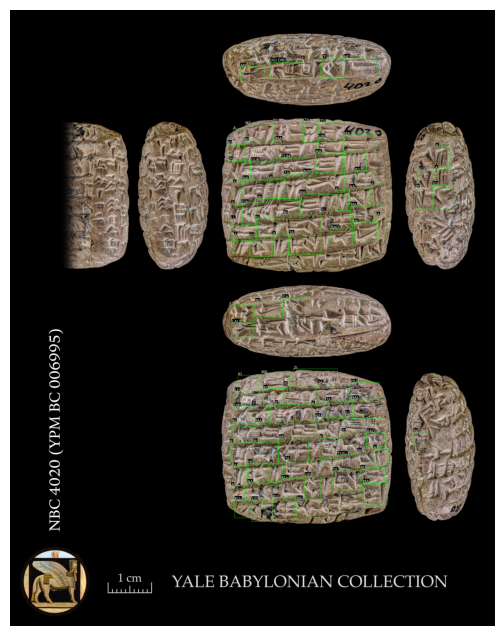

✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_NBC.4020_gt.jpg


In [21]:
# show groud truth boxes
from sign_alignment.visualizer import BboxVisualizer

img = local_source.load_image(sample)
gt_boxes = local_source.load_annotation(sample)
print(f"Ground truth boxes: {gt_boxes}")

gt_bbox_visualizer = BboxVisualizer(color=(0, 255, 0)) # green for gt
gt_bbox_visualizer.draw_boxes(img.copy(), gt_boxes)
# gt_bbox_visualizer.display_result(vis_opt = "save", path = )
gt_bbox_visualizer.show_draw()
gt_bbox_visualizer.save(os.path.join(OUTPUT_DIR, f"debug_{sample}_gt.jpg"))


In [ ]:
# sign text
signs_text = sa.get_signs_from_api(sample)
if signs_text is None:
    raise ValueError(f"No sign text found for sample {sample}")
print(f"  Raw API signs (first 50 chars): {signs_text[:50]}...")

text_lines = sa.parse_api_signs(signs_text)
total_text_signs = sum(len(line) for line in text_lines)
print(f"  Text lines: {len(text_lines)}, total signs: {total_text_signs}")
# print all text lines
text_visualizer = sa.TextVisualizer(text_lines = text_lines)
text_visualizer.write_text_file(filepath = os.path.join(OUTPUT_DIR, f"debug_{sample}_text.txt"), fragment_id=sample)

In [ ]:
# detect signs
tablet_detector = sa.TabletImageDetector(model, sa.CLASSES_ABZ, SCORE_THRESHOLD, keep_crops=True)
detections = tablet_detector.detect(img)

det_bbox_visualizer = sa.BboxVisualizer(boxes_color=(255, 0, 0)) # red for detections
det_bbox_visualizer.draw_boxes(img.copy(), detections)
det_bbox_visualizer.display_result(vis_opt = "save", path = os.path.join(OUTPUT_DIR, f"debug_{sample}_det.jpg"))

cropped = tablet_detector.get_cropped_images()
exp_image = cropped[3]

det_bbox_visualizer.draw_boxes(exp_image.img.copy(), exp_image.detections)
det_bbox_visualizer.display_result(vis_opt = "draw", path = os.path.join(OUTPUT_DIR, f"debug_{sample}_exp_image.jpg"))

In [ ]:
# Transform GT boxes for exp_image (cropped region)
# exp_image is cropped[3], so we need crop_coordinates[3]
exp_image_idx = 3
crop_info = tablet_detector.crop_coordinates[exp_image_idx]

print(f"Crop info for exp_image (index {exp_image_idx}): x={crop_info['x']}, y={crop_info['y']}, w={crop_info['w']}, h={crop_info['h']}")

# Transform GT boxes to exp_image coordinates
gt_boxes_exp = sa.transform_gt_to_cropped_region(gt_boxes, crop_info)
print(f"GT boxes in full image: {len(gt_boxes)}")
print(f"GT boxes in exp_image: {len(gt_boxes_exp)}")

# Visualize GT boxes on exp_image
if gt_boxes_exp:
    gt_exp_bbox_visualizer = sa.BboxVisualizer(boxes_color=(0, 255, 255))  # cyan for gt
    gt_exp_bbox_visualizer.draw_boxes(exp_image.img.copy(), gt_boxes_exp)
    gt_exp_bbox_visualizer.display_result(vis_opt="save", path=os.path.join(OUTPUT_DIR, f"debug_{sample}_exp_gt.jpg"))

In [ ]:
# statistics
avg_width, avg_height = sa.compute_avg_dimensions(detections)
print(f"full image shape: {img.shape}")
print(f"Exp image shape: {exp_image.img.shape}")
print(f"Average detected sign width: {avg_width:.2f}, height: {avg_height:.2f}")

In [ ]:
# Build heatmap for position probability of each class

scale_factor = 10

# Create detection heatmap using extracted function
heatmap, influence_radius, sigma = sa.create_detection_heatmap(
    exp_image.detections, 
    exp_image.img.shape, 
    sa.CLASSES_ABZ, 
    scale_factor=scale_factor,
    avg_width=avg_width,
    avg_height=avg_height,
    method='gaussian'
)

print(f"Original image shape: {exp_image.img.shape[:2]}")
print(f"Created heatmap with shape: {heatmap.shape}")
print(f"Scale factor: 1/{scale_factor}")
print(f"Number of CLASSES_ABZ: {len(sa.CLASSES_ABZ)}")
print(f"Influence radius (scaled): {influence_radius:.2f}, sigma: {sigma:.2f}")
print(f"Heatmap generated with {len(exp_image.detections)} detections")
print(f"Heatmap value range: [{heatmap.min():.3f}, {heatmap.max():.3f}]")


In [ ]:
# Visualize exp image heatmap 

heatmap_visualizer = sa.HeatmapVisualizer()
# find class id for sign name "A"
class_id_for_A = None
class_id_for_NA = None
for i, abz_name in enumerate(sa.CLASSES_ABZ):
    if sa.abz_to_sign_name(abz_name) == "A":
        class_id_for_A = i
        break
for i, abz_name in enumerate(sa.CLASSES_ABZ):
    if sa.abz_to_sign_name(abz_name) == "NA":
        class_id_for_NA = i
        break
print(f"Class ID for sign 'A': {class_id_for_A}")
print(f"Class ID for sign 'NA': {class_id_for_NA}")
    
heatmap_visualizer.draw_heatmap(exp_image.img, heatmap, channels=(class_id_for_A, class_id_for_NA, 2), detection = exp_image.detections)
heatmap_visualizer.display_result(vis_opt = "draw")
heatmap_visualizer.draw_heatmap_pca(exp_image.img, heatmap, detection=exp_image.detections)
heatmap_visualizer.display_result(vis_opt = "draw")

In [ ]:
# Create heatmap from text_lines with synthetic sign positions

# Create text heatmap using extracted function
heatmap_text, margin, influence_radius_text, sigma_text = sa.create_text_heatmap(
    text_lines, 
    sa.CLASSES_ABZ, 
    avg_width, 
    avg_height, 
    scale_factor=scale_factor,
    method='gaussian'
)

max_row_length = max(len(line) for line in text_lines)
num_rows = len(text_lines)
total_signs_in_text = sum(len(line) for line in text_lines)

print(f"Text lines grid: {num_rows} rows, max {max_row_length} columns")
print(f"Average sign dimensions: width={avg_width:.2f}, height={avg_height:.2f}")
print(f"Text heatmap dimensions (after scaling): {heatmap_text.shape}")
print(f"Margin used: {margin:.2f}")
print(f"Gaussian parameters - influence radius: {influence_radius_text:.2f}, sigma: {sigma_text:.2f}")
print(f"Heatmap generated for {total_signs_in_text} signs from text_lines")
print(f"Heatmap value range: [{heatmap_text.min():.3f}, {heatmap_text.max():.3f}]")

In [ ]:
# Visualize text_lines heatmap

# Visualize using the same visualizer
heatmap_visualizer_text = sa.HeatmapVisualizer()

# Use the same class IDs as before for consistency
heatmap_visualizer_text.draw_heatmap(None, heatmap_text, 
                                     channels=(class_id_for_A, class_id_for_NA, 2), 
                                     detection=None, texts=text_lines)
heatmap_visualizer_text.display_result(vis_opt="draw")

In [ ]:
# 1. Use normalized cross-correlation to find template position

print(f"Exp heatmap shape: {heatmap.shape}")
print(f"Text heatmap shape: {heatmap_text.shape}")

# Use extracted matching function
top_left_scaled, max_val, top_left_original = sa.match_heatmaps_ncc(
    heatmap, 
    heatmap_text, 
    scale_factor=scale_factor
)

top_left_x_text = top_left_original[0]
top_left_y_text = top_left_original[1]

print(f"Best match correlation (averaged over {heatmap.shape[2]} classes): {max_val:.4f}")
print(f"Match position in text heatmap (scaled): {top_left_scaled}")
print(f"Match position in text heatmap (original): ({top_left_x_text:.2f}, {top_left_y_text:.2f})")

# Convert to full tablet image coordinates
# The text heatmap starts with margin offset, so we need to subtract that
top_left_x_tablet = top_left_x_text - margin
top_left_y_tablet = top_left_y_text - margin

print(f"Match position in full tablet image: ({top_left_x_tablet:.2f}, {top_left_y_tablet:.2f})")

In [ ]:
# 2. Visualize the position of exp image heatmap in text heatmap

# Create visualization using the mixed heatmaps for display
heatmap_exp_mixed = np.mean(heatmap, axis=2)
heatmap_text_mixed = np.mean(heatmap_text, axis=2)

vis_text_heatmap = cv2.normalize(heatmap_text_mixed, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
vis_text_heatmap_rgb = cv2.cvtColor(vis_text_heatmap, cv2.COLOR_GRAY2RGB)

# Draw rectangle at matched position (in scaled coordinates)
bottom_right_scaled = (top_left_scaled[0] + heatmap_exp_mixed.shape[1], 
                       top_left_scaled[1] + heatmap_exp_mixed.shape[0])
cv2.rectangle(vis_text_heatmap_rgb, top_left_scaled, bottom_right_scaled, (0, 255, 0), 2)

# Display
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 10))
plt.imshow(vis_text_heatmap_rgb)
plt.title(f"Text Heatmap with Matched Exp Image Position (green box)\nCorrelation: {max_val:.4f}")
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Green box shows matched position of exp image in text heatmap")

In [ ]:
# 3. Assign sign centers from text image into exp image and create bboxes

# Get the dimensions of the exp image
exp_img_height, exp_img_width = exp_image.img.shape[:2]

# Use extracted function to create text-based detections
detection_with_texts = sa.create_text_based_detections(
    text_lines, 
    sa.CLASSES_ABZ, 
    top_left_x_text, 
    top_left_y_text, 
    margin, 
    avg_width, 
    avg_height, 
    (exp_img_width, exp_img_height)
)

print(f"Created {len(detection_with_texts)} text-based detections for exp image")
print(f"Original detections: {len(exp_image.detections)}")

# Show first few detections as example
if detection_with_texts:
    print("\nFirst 3 text-based detections:")
    for i, det in enumerate(detection_with_texts[:3]):
        print(f"  {i+1}. {det['abz_name']}: bbox={[f'{x:.1f}' for x in det['bbox']]}, center={det['center']}")

In [ ]:
# 4. Visualize detection_with_texts for exp image

text_det_bbox_visualizer = sa.BboxVisualizer(boxes_color=(0, 0, 255))  # blue for text-based detections
text_det_bbox_visualizer.draw_boxes(exp_image.img.copy(), detection_with_texts)
text_det_bbox_visualizer.display_result(vis_opt="draw", path=os.path.join(OUTPUT_DIR, f"debug_{sample}_text_detections.jpg"))

print(f"Visualized {len(detection_with_texts)} text-based detections on exp image")

In [ ]:
# 5. Organize data using SubTablet data structures

# --- 1. Create SubTablet for detection results (exp_image) ---
sub_tablet_detection = sa.SubTablet.from_detections(
    img=exp_image.img,
    detections=exp_image.detections,
    name="detection",
    avg_width=avg_width,
    avg_height=avg_height
)

# Generate heatmap for detection
sub_tablet_detection.create_heatmap(sa.CLASSES_ABZ, scale_factor=scale_factor, method='gaussian')

print(f"=== SubTablet: Detection ===")
print(f"  Name: {sub_tablet_detection.name}")
print(f"  Image shape: {sub_tablet_detection.shape}")
print(f"  Num sign boxes: {len(sub_tablet_detection)}")
print(f"  Avg dimensions: {sub_tablet_detection.avg_width:.2f} x {sub_tablet_detection.avg_height:.2f}")
print(f"  Heatmap shape: {sub_tablet_detection.heatmap.shape}")

# --- 2. Create SubTablet for full text (hypothetical full tablet from API text) ---
sub_tablet_full_text = sa.SubTablet.from_text_lines(
    text_lines=text_lines,
    avg_width=avg_width,
    avg_height=avg_height,
    margin=margin,
    name="full_text"
)

# Generate heatmap for full text
sub_tablet_full_text.create_heatmap(sa.CLASSES_ABZ, scale_factor=scale_factor, method='gaussian')

print(f"\n=== SubTablet: Full Text ===")
print(f"  Name: {sub_tablet_full_text.name}")
print(f"  Estimated shape: {sub_tablet_full_text.shape}")
print(f"  Num sign boxes: {len(sub_tablet_full_text)}")
print(f"  Margin: {sub_tablet_full_text.margin:.2f}")
print(f"  Heatmap shape: {sub_tablet_full_text.heatmap.shape}")

# --- 3. Create SubTablet for text-aligned signs (detection_with_texts) ---
# This represents the text signs that fall within the exp image region
sub_tablet_text_aligned = sub_tablet_full_text.extract_sub_region(
    offset_x=top_left_x_text,
    offset_y=top_left_y_text,
    width=exp_img_width,
    height=exp_img_height,
    img=exp_image.img,
    name="text_aligned"
)

# Generate heatmap for text-aligned (using image dimensions)
sub_tablet_text_aligned.create_heatmap(
    sa.CLASSES_ABZ, 
    scale_factor=scale_factor,
    img_shape=exp_image.img.shape,
    method='gaussian'
)

print(f"\n=== SubTablet: Text Aligned ===")
print(f"  Name: {sub_tablet_text_aligned.name}")
print(f"  Image shape: {sub_tablet_text_aligned.shape}")
print(f"  Num sign boxes: {len(sub_tablet_text_aligned)}")
print(f"  Origin offset: ({sub_tablet_text_aligned.origin_x:.2f}, {sub_tablet_text_aligned.origin_y:.2f})")
print(f"  Heatmap shape: {sub_tablet_text_aligned.heatmap.shape}")

# --- Verify consistency with previous results ---
print(f"\n=== Verification ===")
print(f"  detection_with_texts count: {len(detection_with_texts)}")
print(f"  sub_tablet_text_aligned count: {len(sub_tablet_text_aligned)}")

# Show first 3 sign boxes from each
print(f"\n  First 3 from sub_tablet_detection:")
for i, sb in enumerate(sub_tablet_detection.sign_boxes[:3]):
    print(f"    {i+1}. {sb.sign_name}: center=({sb.cx:.1f}, {sb.cy:.1f}), size=({sb.width:.1f}, {sb.height:.1f})")

print(f"\n  First 3 from sub_tablet_text_aligned:")
for i, sb in enumerate(sub_tablet_text_aligned.sign_boxes[:3]):
    print(f"    {i+1}. {sb.sign_name}: center=({sb.cx:.1f}, {sb.cy:.1f}), size=({sb.width:.1f}, {sb.height:.1f})")

In [ ]:
# 6. Visualize SubTablet data using existing visualizers

# The to_detection_list() method converts SignBoxes back to detection dict format
# This ensures compatibility with existing BboxVisualizer

from re import sub
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Visualize detection SubTablet
det_vis_img = sub_tablet_detection.img.copy()
det_vis = sa.BboxVisualizer(boxes_color=(255, 0, 0))  # Red for detection
det_vis.draw_boxes(det_vis_img, sub_tablet_detection.to_detection_list())
axes[0].imshow(cv2.cvtColor(det_vis.visualized_result, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Detection ({len(sub_tablet_detection)} signs)")
axes[0].axis('off')

# Visualize text-aligned SubTablet
text_vis_img = sub_tablet_text_aligned.img.copy()
text_vis = sa.BboxVisualizer(boxes_color=(0, 0, 255))  # Blue for text-aligned
text_vis.draw_boxes(text_vis_img, sub_tablet_text_aligned.to_detection_list())
axes[1].imshow(cv2.cvtColor(text_vis.visualized_result, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Text Aligned ({len(sub_tablet_text_aligned)} signs)")
axes[1].axis('off')

# Overlay both on same image
overlay_img = sub_tablet_detection.img.copy()
det_overlay = sa.BboxVisualizer(boxes_color=(255, 0, 0))  # Red for detection
det_overlay.draw_boxes(overlay_img, sub_tablet_detection.to_detection_list())
text_overlay = sa.BboxVisualizer(boxes_color=(0, 0, 255))  # Blue for text
text_overlay.draw_boxes(det_overlay.visualized_result, sub_tablet_text_aligned.to_detection_list())
axes[2].imshow(cv2.cvtColor(text_overlay.visualized_result, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Overlay: Detection (red) + Text Aligned (blue)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("Red = Detection results, Blue = Text-aligned bboxes")

heatmap_visualizer_opt = sa.HeatmapVisualizer(bboxes_color=(200, 0, 200))
heatmap_visualizer_opt.draw_heatmap_pca(sub_tablet_detection.img, sub_tablet_detection.heatmap, detection = sub_tablet_detection.to_detection_list())
heatmap_visualizer_opt.display_result(vis_opt = "draw")
heatmap_visualizer_opt.draw_heatmap(sub_tablet_detection.img, sub_tablet_detection.heatmap, channels=(class_id_for_A, class_id_for_NA, 2), detection = sub_tablet_detection.to_detection_list())
heatmap_visualizer_opt.display_result(vis_opt = "draw")

heatmap_visualizer_opt.draw_heatmap_pca(sub_tablet_text_aligned.img, sub_tablet_text_aligned.heatmap, detection = sub_tablet_text_aligned.to_detection_list())
heatmap_visualizer_opt.display_result(vis_opt = "draw")
heatmap_visualizer_opt.draw_heatmap(sub_tablet_text_aligned.img, sub_tablet_text_aligned.heatmap, channels=(class_id_for_A, class_id_for_NA, 2), detection = sub_tablet_text_aligned.to_detection_list())
heatmap_visualizer_opt.display_result(vis_opt = "draw")

In [ ]:
# 7. Elastic Chain Optimization - Refine text-aligned bboxes using detection heatmap

# Create the optimizer
optimizer = sa.ElasticChainOptimizer(
    sub_tablet_text=sub_tablet_text_aligned,
    detection_heatmap=sub_tablet_detection.heatmap,
    CLASSES_ABZ=sa.CLASSES_ABZ,
    scale_factor=scale_factor,
    lambda_data=10000.0,      # Weight for heatmap matching
    lambda_seq=0.05,       # Weight for sequential constraint (tight row distribution)
    lambda_smooth=0.15,   # Weight for height consistency
    lambda_anchor=0.05,   # Weight for baseline anchor
    # lambda_data=1.0,      # Higher weight for heatmap matching
    # lambda_seq=0.00,      # Lower sequential constraint
    # lambda_smooth=0.00,   # Lower smoothness
    # lambda_anchor=0.00,   # Lower anchor
    prior_aspect_ratio=avg_width / avg_height,  # Use observed aspect ratio as prior
    device=device
)

print(f"=== Elastic Chain Optimizer Initialized ===")
print(f"  Device: {optimizer.device}")
print(f"  Number of signs: {optimizer.num_signs}")
print(f"  Number of rows: {optimizer.num_rows}")
print(f"  Prior aspect ratio: {optimizer.prior_aspect_ratio:.3f}")
print(f"  Heatmap shape: {optimizer.heatmap.shape}")

# Run optimization with a few iterations (experimental)
sub_tablet_optimized = optimizer.optimize(
    num_iterations=100,
    lr=5.0,
    verbose=True,
    log_every=5
)

In [ ]:
# 7.5 Debug: Analyze data loss gradient and heatmap values

# Check if gradients are flowing properly
test_optimizer = sa.ElasticChainOptimizer(
    sub_tablet_text=sub_tablet_text_aligned,
    detection_heatmap=sub_tablet_detection.heatmap,
    CLASSES_ABZ=sa.CLASSES_ABZ,
    scale_factor=scale_factor,
    lambda_data=1.0,
    lambda_seq=0.0,  # disable other losses
    lambda_smooth=0.0,
    lambda_anchor=0.0,
    device=device
)

# Compute loss and gradients
loss = test_optimizer.compute_data_loss()
loss.backward()

# Check gradients
grads = test_optimizer.params.grad
print("=== Data Loss Gradient Analysis ===")
print(f"L_data = {loss.item():.4f}")
print(f"Gradient statistics:")
print(f"  cx grad: mean={grads[:, 0].mean().item():.6f}, std={grads[:, 0].std().item():.6f}, max={grads[:, 0].abs().max().item():.6f}")
print(f"  cy grad: mean={grads[:, 1].mean().item():.6f}, std={grads[:, 1].std().item():.6f}, max={grads[:, 1].abs().max().item():.6f}")
print(f"  w grad:  mean={grads[:, 2].mean().item():.6f}, std={grads[:, 2].std().item():.6f}")
print(f"  h grad:  mean={grads[:, 3].mean().item():.6f}, std={grads[:, 3].std().item():.6f}")

# Analyze heatmap values at sign positions
print("\n=== Heatmap Values at Text-Aligned Sign Positions ===")
heatmap_h, heatmap_w = sub_tablet_detection.heatmap.shape[:2]
values_at_positions = []

for i, sb in enumerate(sub_tablet_text_aligned.sign_boxes[:10]):
    # Get class id
    if sb.abz_name in sa.CLASSES_ABZ:
        class_id = sa.CLASSES_ABZ.index(sb.abz_name)
    else:
        continue
    
    # Get scaled position
    sx = int(sb.cx / scale_factor)
    sy = int(sb.cy / scale_factor)
    
    if 0 <= sy < heatmap_h and 0 <= sx < heatmap_w:
        val = sub_tablet_detection.heatmap[sy, sx, class_id]
        values_at_positions.append(val)
        print(f"  {i+1}. {sb.sign_name} (class_id={class_id}): pos=({sx},{sy}), heatmap_val={val:.4f}")

print(f"\nMean heatmap value at text positions: {np.mean(values_at_positions):.4f}")
print(f"Max heatmap value at text positions: {np.max(values_at_positions):.4f}")

# Check heatmap max values for these classes
print("\n=== Max Heatmap Values for Each Class ===")
for i, sb in enumerate(sub_tablet_text_aligned.sign_boxes[:5]):
    if sb.abz_name in sa.CLASSES_ABZ:
        class_id = sa.CLASSES_ABZ.index(sb.abz_name)
        max_val = sub_tablet_detection.heatmap[:, :, class_id].max()
        print(f"  {sb.sign_name} (class_id={class_id}): max_heatmap={max_val:.4f}")

In [ ]:
# 8. Visualize Optimization Results

# Plot loss history
optimizer.plot_loss_history()

# Visualize comparison: before vs after optimization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Before: Text-aligned (blue)
before_img = sub_tablet_text_aligned.img.copy()
before_vis = sa.BboxVisualizer(boxes_color=(0, 0, 255))
before_vis.draw_boxes(before_img, sub_tablet_text_aligned.to_detection_list())
axes[0, 0].imshow(cv2.cvtColor(before_vis.visualized_result, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title(f"Before: Text Aligned ({len(sub_tablet_text_aligned)} signs)")
axes[0, 0].axis('off')

# After: Optimized (green)
after_img = sub_tablet_optimized.img.copy()
after_vis = sa.BboxVisualizer(boxes_color=(0, 255, 255))
after_vis.draw_boxes(after_img, sub_tablet_optimized.to_detection_list())
axes[0, 1].imshow(cv2.cvtColor(after_vis.visualized_result, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title(f"After: Optimized ({len(sub_tablet_optimized)} signs)")
axes[0, 1].axis('off')

# Overlay: Detection (red) + Optimized (green)
overlay_img = sub_tablet_detection.img.copy()
det_vis_overlay = sa.BboxVisualizer(boxes_color=(255, 0, 0))
det_vis_overlay.draw_boxes(overlay_img, sub_tablet_detection.to_detection_list())
opt_vis_overlay = sa.BboxVisualizer(boxes_color=(0, 255, 255))
opt_vis_overlay.draw_boxes(det_vis_overlay.visualized_result, sub_tablet_optimized.to_detection_list())
axes[1, 0].imshow(cv2.cvtColor(opt_vis_overlay.visualized_result, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title(f"Overlay: Detection (red) + Optimized (green)")
axes[1, 0].axis('off')

# Overlay: Optimized + Ground Truth
# Use gt_boxes_exp from earlier cell (already transformed to exp_image coordinates)
overlay_img_gt = sub_tablet_optimized.img.copy()
gt_vis_overlay = sa.BboxVisualizer(boxes_color=(0, 255, 0))  # green for ground truth
gt_vis_overlay.draw_boxes(overlay_img_gt, gt_boxes_exp)
opt_vis_overlay_gt = sa.BboxVisualizer(boxes_color=(0, 255, 255))  # cyan for optimized
opt_vis_overlay_gt.draw_boxes(gt_vis_overlay.visualized_result, sub_tablet_optimized.to_detection_list())
axes[1, 1].imshow(cv2.cvtColor(opt_vis_overlay_gt.visualized_result, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title(f"Overlay: Optimized (cyan) + Ground Truth (green)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("Blue = Text-aligned (before), Green = Optimized (after), Red = Detection, Cyan = Ground Truth")

In [ ]:
# 9. Analyze Parameter Changes

# Get parameter changes
param_changes = optimizer.get_param_changes()

print("=== Parameter Changes Summary ===")
print(f"  Mean delta_cx: {param_changes[:, 0].mean():.2f} (std: {param_changes[:, 0].std():.2f})")
print(f"  Mean delta_cy: {param_changes[:, 1].mean():.2f} (std: {param_changes[:, 1].std():.2f})")
print(f"  Mean delta_w:  {param_changes[:, 2].mean():.2f} (std: {param_changes[:, 2].std():.2f})")
print(f"  Mean delta_h:  {param_changes[:, 3].mean():.2f} (std: {param_changes[:, 3].std():.2f})")

# Compare first few signs before/after
print("\n=== First 5 Signs: Before vs After ===")
for i in range(min(5, len(sub_tablet_text_aligned.sign_boxes))):
    before = sub_tablet_text_aligned.sign_boxes[i]
    after = sub_tablet_optimized.sign_boxes[i]
    print(f"  {i+1}. {before.sign_name}:")
    print(f"      Before: cx={before.cx:.1f}, cy={before.cy:.1f}, w={before.width:.1f}, h={before.height:.1f}")
    print(f"      After:  cx={after.cx:.1f}, cy={after.cy:.1f}, w={after.width:.1f}, h={after.height:.1f}")
    print(f"      Delta:  Δcx={after.cx-before.cx:.1f}, Δcy={after.cy-before.cy:.1f}, Δw={after.width-before.width:.1f}, Δh={after.height-before.height:.1f}")